# Data Preprocessing 


**Pre-processing pipeline notes** 


In [2]:
#Import libraries for preprocessing 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.ensemble import RandomForestRegressor
from scipy.signal import savgol_filter

import warnings
warnings.filterwarnings('ignore')



## Data exploration

In [3]:
df= pd.read_csv('raw_data/aved_raw.csv')
df.head() 

,time,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 1.N2O value,BIOLOGY.LINE 3 TANK 1.N2O quality,BIOLOGY.LINE 3 TANK 1.NH4 value,BIOLOGY.LINE 3 TANK 1.NH4 quality,BIOLOGY.LINE 3 TANK 1.NO3 value,...,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK quality,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK quality,BIOLOGY.LINE 3 TANK 1.PO4 value,BIOLOGY.LINE 3 TANK 1.PO4 quality,INLET.Q value,INLET.Q quality,INLET.STATE.SWM INLET FLOW value,INLET.STATE.SWM INLET FLOW quality
0,2022-06-12 00:01:00+02:00,26829.375000,1.0,NaN,NaN,0.700231,0.0,1.66608,0.0,0.074907,...,NaN,NaN,NaN,NaN,0.285834,1.0,NaN,NaN,NaN,NaN
1,2022-06-12 00:02:00+02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2,2022-06-12 00:03:00+02:00,29626.341797,1.0,NaN,NaN,0.697917,0.0,1.52727,0.0,0.074907,...,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN
3,2022-06-12 00:04:00+02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
4,2022-06-12 00:05:00+02:00,28605.208984,1.0,NaN,NaN,0.656829,0.0,1.43633,0.0,0.056901,...,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN


In [4]:
#Check shape of dataset 
shape = df.shape
print(f"The dataset contains {shape[0]} rows and {shape[1]} columns.")

The dataset contains 906815 rows and 49 columns.


In [5]:
#Data types of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906815 entries, 0 to 906814
Data columns (total 49 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   time                                             906815 non-null  object 
 1   BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value          520588 non-null  float64
 2   BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality        520588 non-null  float64
 3   BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value          502835 non-null  float64
 4   BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality        502835 non-null  float64
 5   BIOLOGY.LINE 3 TANK 1.N2O value                  520546 non-null  float64
 6   BIOLOGY.LINE 3 TANK 1.N2O quality                520546 non-null  float64
 7   BIOLOGY.LINE 3 TANK 1.NH4 value                  520595 non-null  float64
 8   BIOLOGY.LINE 3 TANK 1.NH4 quality                520595 non-null  float64
 9   BIOLOGY.LINE 3 

In [6]:
df.describe().round(2) 

,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 1.N2O value,BIOLOGY.LINE 3 TANK 1.N2O quality,BIOLOGY.LINE 3 TANK 1.NH4 value,BIOLOGY.LINE 3 TANK 1.NH4 quality,BIOLOGY.LINE 3 TANK 1.NO3 value,BIOLOGY.LINE 3 TANK 1.NO3 quality,...,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK quality,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK quality,BIOLOGY.LINE 3 TANK 1.PO4 value,BIOLOGY.LINE 3 TANK 1.PO4 quality,INLET.Q value,INLET.Q quality,INLET.STATE.SWM INLET FLOW value,INLET.STATE.SWM INLET FLOW quality
count,520588.00,520588.00,502835.00,502835.0,520546.00,520546.00,520595.00,520595.00,520583.00,520583.00,...,526285.00,526285.0,526285.00,526285.0,520593.00,520593.00,454082.00,454082.00,526287.00,526287.0
mean,17132.97,0.08,44.47,0.0,0.10,0.13,2.31,0.11,2.78,0.05,...,1.47,0.0,1.50,0.0,1.12,0.04,3080.39,0.02,0.14,0.0
std,7341.11,0.28,42.04,0.0,0.24,0.34,2.21,0.31,2.78,0.22,...,0.52,0.0,0.52,0.0,0.96,0.19,2327.10,0.14,0.34,0.0
min,0.00,0.00,0.00,0.0,-0.02,0.00,-0.00,0.00,-0.34,0.00,...,0.00,0.0,0.00,0.0,0.00,0.00,-5572.45,0.00,0.00,0.0
25%,11565.40,0.00,0.00,0.0,-0.01,0.00,0.95,0.00,1.18,0.00,...,1.00,0.0,1.00,0.0,0.51,0.00,2095.49,0.00,0.00,0.0
50%,16800.33,0.00,40.70,0.0,0.01,0.00,1.87,0.00,2.18,0.00,...,1.00,0.0,2.00,0.0,0.89,0.00,2303.82,0.00,0.00,0.0
75%,21809.08,0.00,89.20,0.0,0.11,0.00,3.03,0.00,3.73,0.00,...,2.00,0.0,2.00,0.0,1.44,0.00,4328.12,0.00,0.00,0.0
max,43356.56,1.00,100.00,0.0,12.00,1.00,20.01,1.00,52.66,1.00,...,2.00,0.0,2.00,0.0,16.56,1.00,17192.57,1.00,1.00,0.0


### Date-time Index

In [7]:
#Set time column to datetime
df['time'] = pd.to_datetime(df['time'], errors='coerce', utc=True)

#Check unparsable dates
unparsable_dates = df['time'].isnull().sum()
print(f"Number of unparsable dates in 'time' column: {unparsable_dates}")

#Check time data type and range
print(df['time'].dtype)
print(f"Time range: {df['time'].min()} to {df['time'].max()}")

#Set time as index 
df.set_index('time', inplace=True)

Number of unparsable dates in 'time' column: 0
datetime64[ns, UTC]
Time range: 2022-06-11 22:01:00+00:00 to 2024-06-11 21:59:00+00:00


### Remove Duplicates 

In [8]:
df = df.copy()

#Check for exact duplicates 
duplicate_rows = df.duplicated() 
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

#Drop exact duplicates 
df = df[~duplicate_rows].copy()

#Check duplicate 
time_duplicates = df.index.duplicated()
print(f"Number of duplicate timestamps: {time_duplicates.sum()}")

#Drop duplicated timestamps, keeping the first occurrence
df = df[~df.index.duplicated(keep="first")].copy()

print(f"Dataset shape after removing duplicates: {df.shape}")

Number of duplicate rows: 108349
Number of duplicate timestamps: 0
Dataset shape after removing duplicates: (798466, 48)


**Note:** shape likely different because no variables have been dropped yet (compared to example from lectures which has 622109 rows).

### Clean Variable Names

Create clean variable names

In [9]:
df_renamed = df.rename(columns={
    'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value': 'total_airflow',
    'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality': 'total_airflow_q',

    'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value': 't1_valve_pct',
    'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality': 't1_valve_pct_q',

    'BIOLOGY.LINE 3 TANK 1.N2O value': 't1_n2o',
    'BIOLOGY.LINE 3 TANK 1.N2O quality': 't1_n2o_q',

    'BIOLOGY.LINE 3 TANK 1.NH4 value': 't1_nh4',
    'BIOLOGY.LINE 3 TANK 1.NH4 quality': 't1_nh4_q',

    'BIOLOGY.LINE 3 TANK 1.NO3 value': 't1_no3',
    'BIOLOGY.LINE 3 TANK 1.NO3 quality': 't1_no3_q',

    'BIOLOGY.LINE 3 TANK 1.O2 value': 't1_do', #dissolved oxygen concentration in tank 1
    'BIOLOGY.LINE 3 TANK 1.O2 quality': 't1_do_q',

    'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value': 't1_do_sp', #controller target for DO concentration in tank 1
    'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality': 't1_do_sp_q',

    'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value': 't1_phase', # 0 - anaerobic, 1 - anoxic, 2 - aerobic
    'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE quality': 't1_phase_q',

    'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value': 't1_airflow',
    'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality': 't1_airflow_q',

    'BIOLOGY.LINE 3 TANK 1.SS value': 't1_ss', #tank 1 - suspended solids concentration - biomass proxy
    'BIOLOGY.LINE 3 TANK 1.SS quality': 't1_ss_q',

    'BIOLOGY.LINE 3 TANK 1.TEMPERATURE value': 't1_temp', 
    'BIOLOGY.LINE 3 TANK 1.TEMPERATURE quality': 't1_temp_q',

    'BIOLOGY.LINE 3 TANK 2 VALVE 1.PCT value': 't2_valve_pct',
    'BIOLOGY.LINE 3 TANK 2 VALVE 1.PCT quality': 't2_valve_pct_q',

    'BIOLOGY.LINE 3 TANK 2.O2 value': 't2_do', #dissolved oxygen concentration in tank 2
    'BIOLOGY.LINE 3 TANK 2.O2 quality': 't2_do_q',

    'BIOLOGY.LINE 3 TANK 2.O2.SETPOINT value': 't2_do_sp', #controller target for DO concentration in tank 2
    'BIOLOGY.LINE 3 TANK 2.O2.SETPOINT quality': 't2_do_sp_q',

    'BIOLOGY.LINE 3 TANK 2.PROCESSPHASE value': 't2_phase', # 0 - anaerobic, 1 - anoxic, 2 - aerobic
    'BIOLOGY.LINE 3 TANK 2.PROCESSPHASE quality': 't2_phase_q',

    'BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW value': 't2_airflow',
    'BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW quality': 't2_airflow_q',

    'BIOLOGY.LINE 3 TANK 2.SS value': 't2_ss', #tank 2 - suspended solids concentration - biomass proxy
    'BIOLOGY.LINE 3 TANK 2.SS quality': 't2_ss_q',

    'BIOLOGY.LINE 3 TANK 2.TEMPERATURE value': 't2_temp', 
    'BIOLOGY.LINE 3 TANK 2.TEMPERATURE quality': 't2_temp_q',

    'BIOLOGY.LINE 3.PHASECODE.SETPOINT value': 'phasecode', #system wide phase code setpoint - indicates which phase of the process the system is in (e.g., aeration, anoxic, etc.)
    'BIOLOGY.LINE 3.PHASECODE.SETPOINT quality': 'phasecode_q',

    'BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK value': 'inlet_tank',
    'BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK quality': 'inlet_tank_q',

    'BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK value': 'outlet_tank',
    'BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK quality': 'outlet_tank_q',

    'BIOLOGY.LINE 3 TANK 1.PO4 value': 't1_po4', #tank 1 - PO4 concentration
    'BIOLOGY.LINE 3 TANK 1.PO4 quality': 't1_po4_q',

    'INLET.Q value': 'inflow', #Total influent flow 
    'INLET.Q quality': 'inflow_q',

    'INLET.STATE.SWM INLET FLOW value': 'storm_mode', #Binary variable indicating storm conditions 
    'INLET.STATE.SWM INLET FLOW quality': 'storm_mode_q'

}).copy()



In [10]:
df_renamed.head()

,total_airflow,total_airflow_q,t1_valve_pct,t1_valve_pct_q,t1_n2o,t1_n2o_q,t1_nh4,t1_nh4_q,t1_no3,t1_no3_q,...,inlet_tank,inlet_tank_q,outlet_tank,outlet_tank_q,t1_po4,t1_po4_q,inflow,inflow_q,storm_mode,storm_mode_q
time,,,,,,,,,,,,,,,,,,,,,
2022-06-11 22:01:00+00:00,26829.375000,1.0,NaN,NaN,0.700231,0.0,1.66608,0.0,0.074907,0.0,...,NaN,NaN,NaN,NaN,0.285834,1.0,NaN,NaN,NaN,NaN
2022-06-11 22:02:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2022-06-11 22:03:00+00:00,29626.341797,1.0,NaN,NaN,0.697917,0.0,1.52727,0.0,0.074907,0.0,...,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN
2022-06-11 22:04:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2022-06-11 22:05:00+00:00,28605.208984,1.0,NaN,NaN,0.656829,0.0,1.43633,0.0,0.056901,0.0,...,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN


In [11]:
#Drop data for tank 2 

df_renamed_t1 = df_renamed.drop(columns=[col for col in df_renamed.columns if col.startswith('t2_')]).copy()

In [12]:
df_renamed_t1.head()

,total_airflow,total_airflow_q,t1_valve_pct,t1_valve_pct_q,t1_n2o,t1_n2o_q,t1_nh4,t1_nh4_q,t1_no3,t1_no3_q,...,inlet_tank,inlet_tank_q,outlet_tank,outlet_tank_q,t1_po4,t1_po4_q,inflow,inflow_q,storm_mode,storm_mode_q
time,,,,,,,,,,,,,,,,,,,,,
2022-06-11 22:01:00+00:00,26829.375000,1.0,NaN,NaN,0.700231,0.0,1.66608,0.0,0.074907,0.0,...,NaN,NaN,NaN,NaN,0.285834,1.0,NaN,NaN,NaN,NaN
2022-06-11 22:02:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2022-06-11 22:03:00+00:00,29626.341797,1.0,NaN,NaN,0.697917,0.0,1.52727,0.0,0.074907,0.0,...,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN
2022-06-11 22:04:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2022-06-11 22:05:00+00:00,28605.208984,1.0,NaN,NaN,0.656829,0.0,1.43633,0.0,0.056901,0.0,...,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN


## Data structure & challenges 

### Missing values 

In [13]:
df_t1 = df_renamed_t1.copy()

#Check for missing values per variable 

missing_values = df_t1.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
total_airflow      277932
total_airflow_q    277932
t1_valve_pct       296380
t1_valve_pct_q     296380
t1_n2o             292707
t1_n2o_q           292707
t1_nh4             277918
t1_nh4_q           277918
t1_no3             278815
t1_no3_q           278815
t1_do              288170
t1_do_q            288170
t1_do_sp           362255
t1_do_sp_q         362255
t1_phase           281340
t1_phase_q         281340
t1_airflow         328293
t1_airflow_q       328293
t1_ss              277883
t1_ss_q            277883
t1_temp            293256
t1_temp_q          293256
phasecode          362255
phasecode_q        362255
inlet_tank         362255
inlet_tank_q       362255
outlet_tank        362255
outlet_tank_q      362255
t1_po4             280376
t1_po4_q           280376
inflow             346532
inflow_q           346532
storm_mode         362253
storm_mode_q       362253
dtype: int64


In [14]:
#Create df with only value columns (drop quality columns) for plots 
value_columns = [col for col in df_t1.columns if not col.endswith('_q')]
df_values = df_t1[value_columns].copy()

In [15]:
print("Columns in df_values:")
print(df_values.columns)

Columns in df_values:
Index(['total_airflow', 't1_valve_pct', 't1_n2o', 't1_nh4', 't1_no3', 't1_do',
       't1_do_sp', 't1_phase', 't1_airflow', 't1_ss', 't1_temp', 'phasecode',
       'inlet_tank', 'outlet_tank', 't1_po4', 'inflow', 'storm_mode'],
      dtype='object')


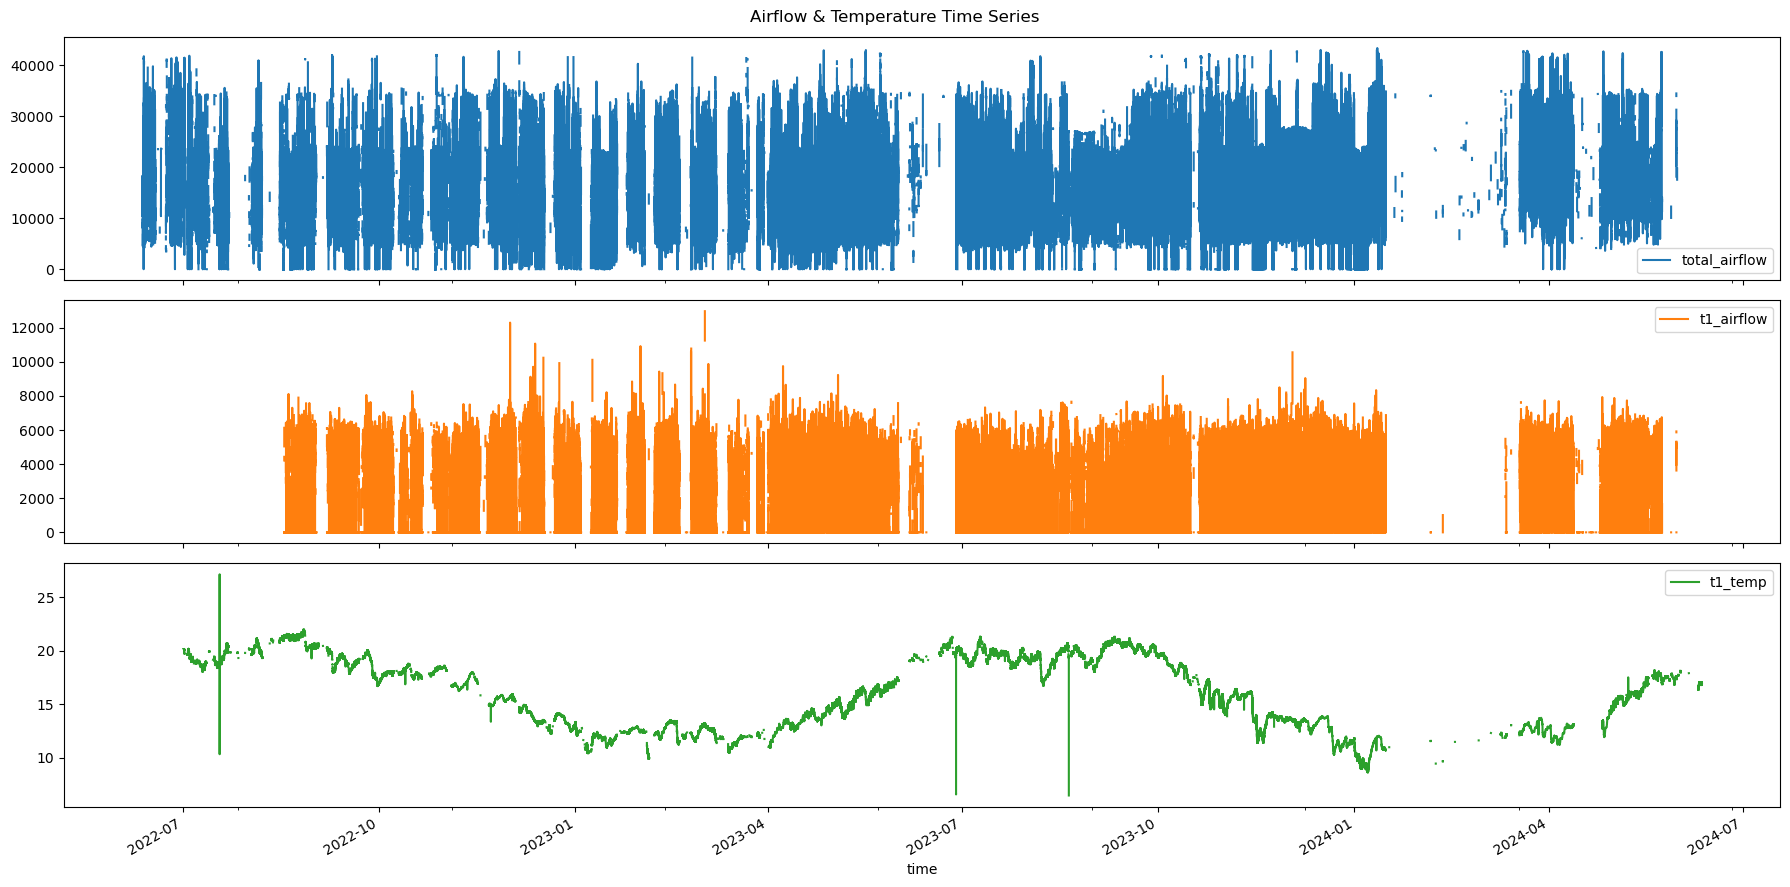

In [45]:
#Plot time series of each variable to check for trends, seasonality, and outliers

#Plot - airflow + temperature 
df_values[['total_airflow', 't1_airflow', 't1_temp']].plot(subplots=True, figsize=(18, 9), title='Airflow & Temperature Time Series')
plt.tight_layout()
plt.show()

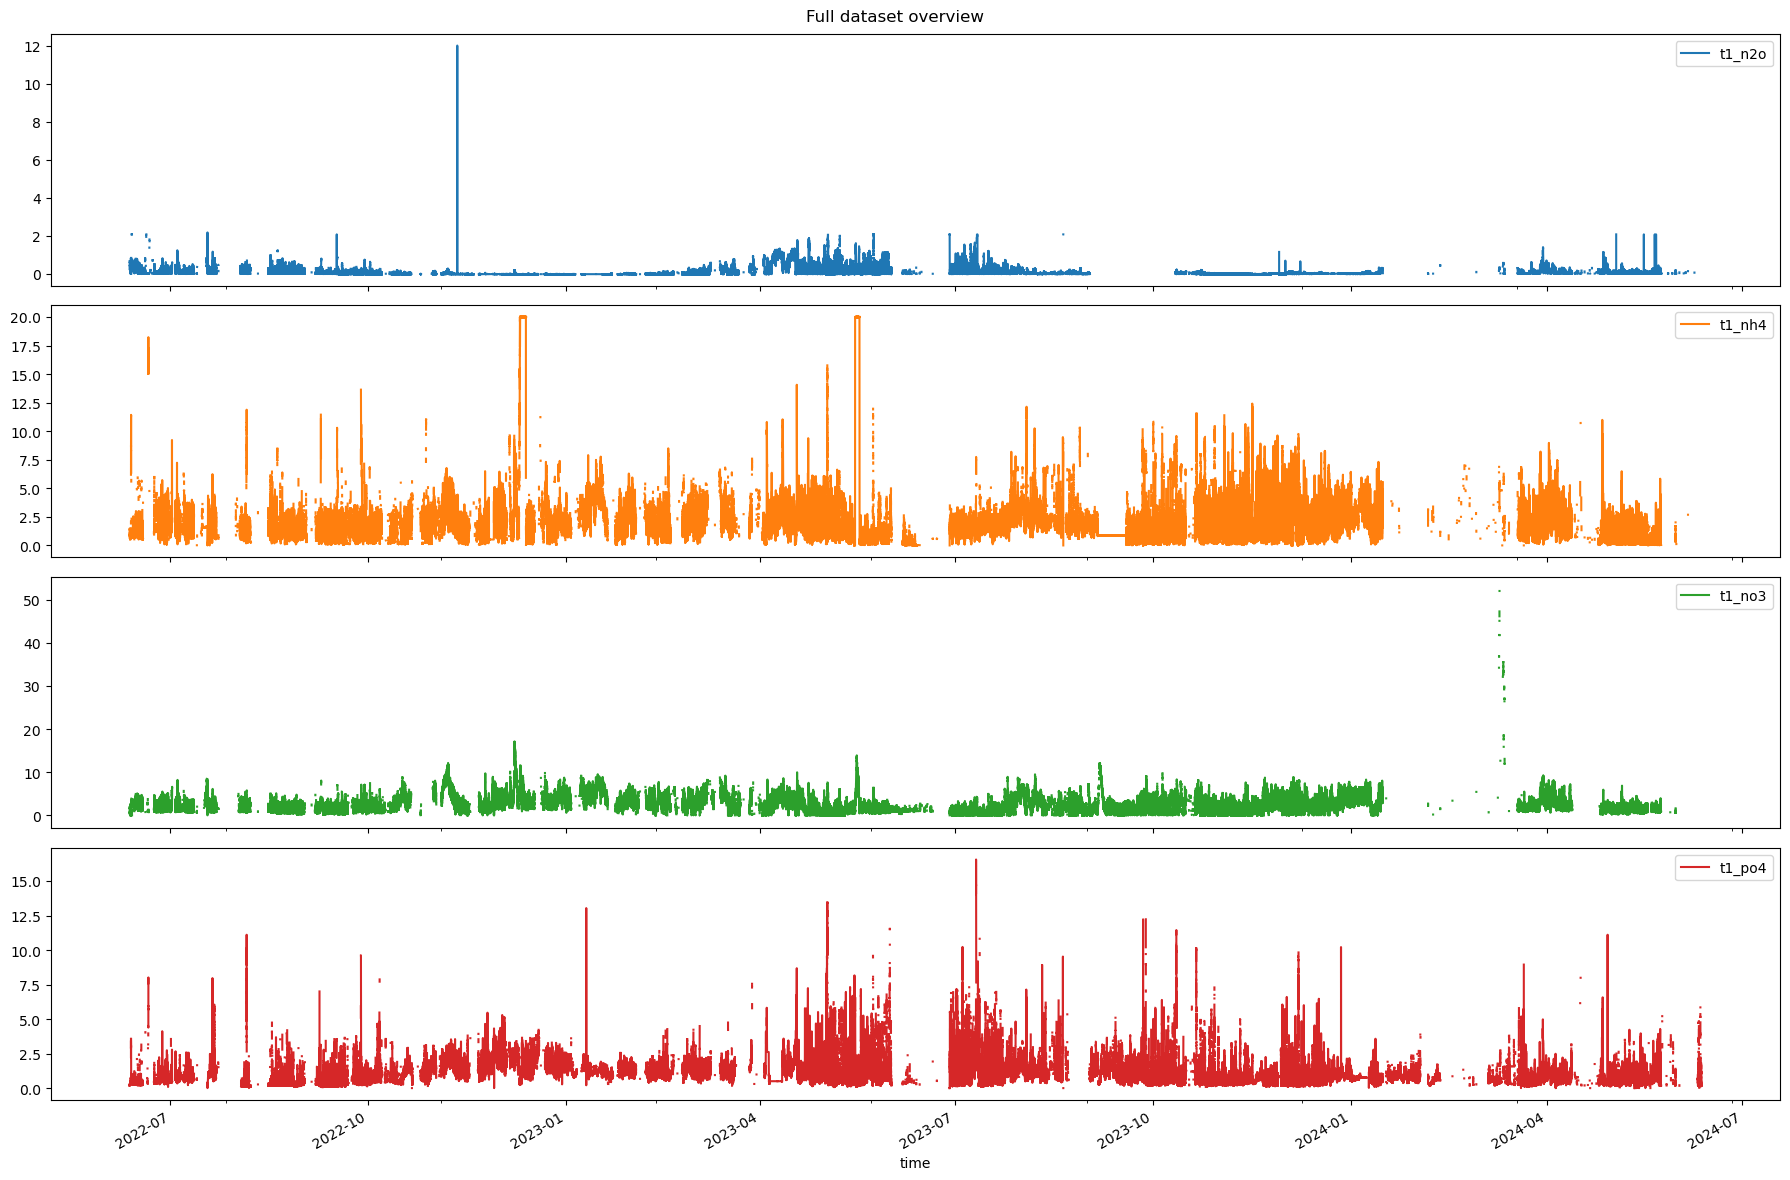

In [46]:
#Plots of N2O (target), NH4, NO3 and PO4 (nutrient concentrations)
df_values[['t1_n2o', 't1_nh4', 't1_no3', 't1_po4']].plot(subplots=True, figsize=(18, 12), title='Full dataset overview')        
plt.tight_layout()
plt.show()

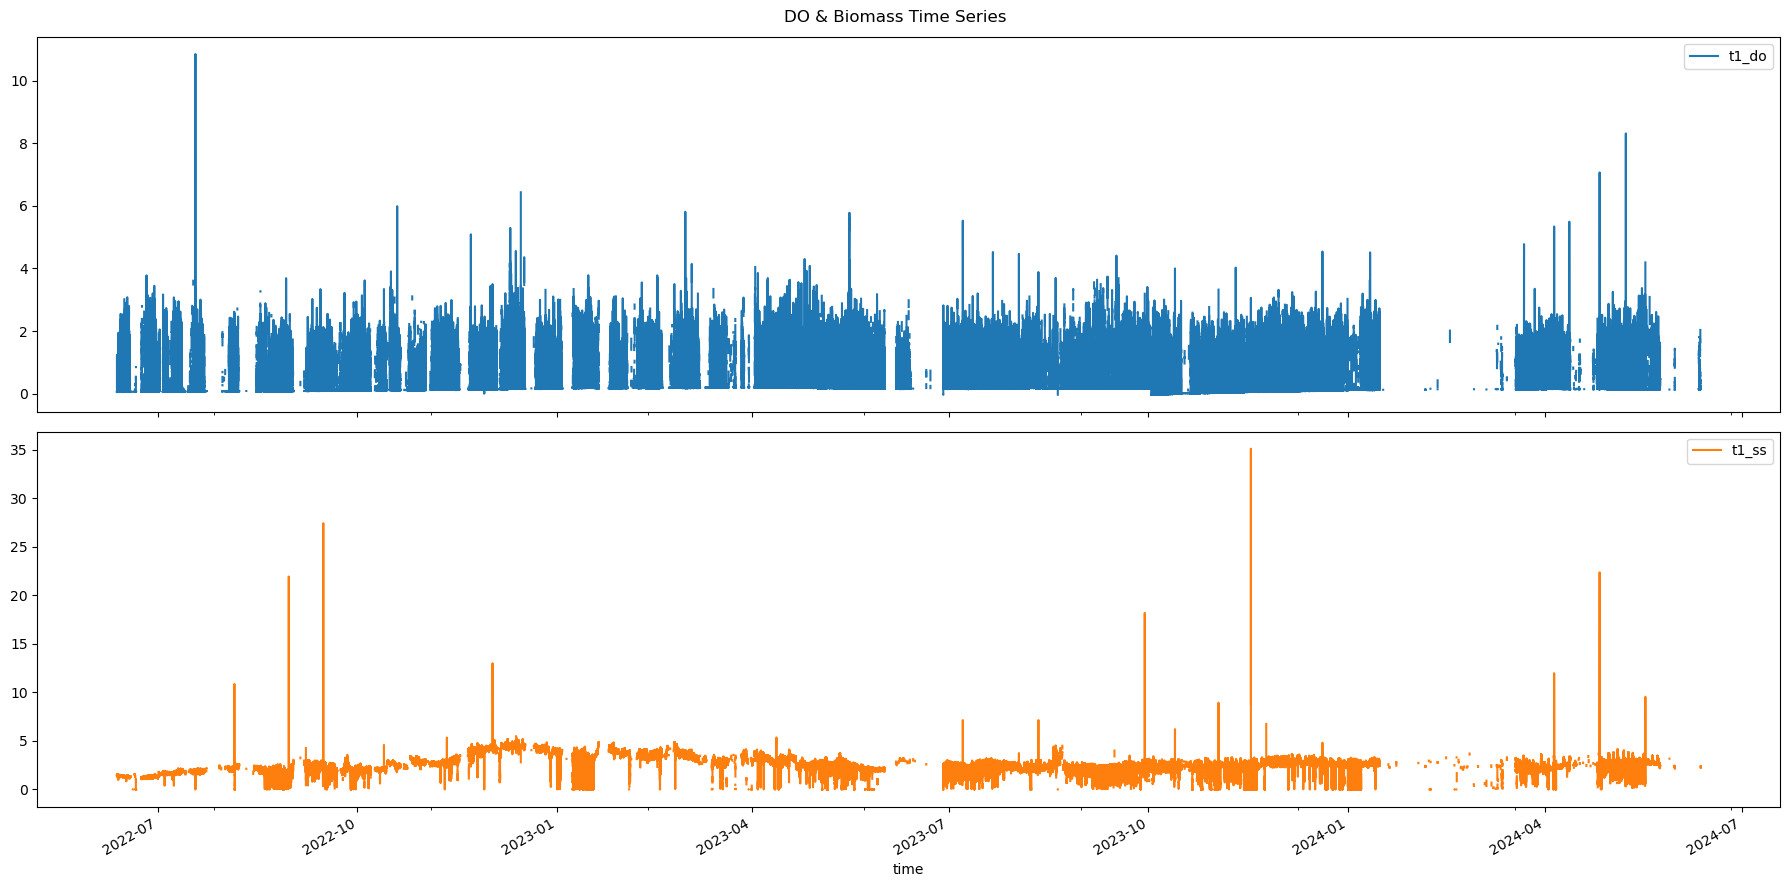

In [48]:
#Plots for DO variables and SS (biomass proxy)
df_values[['t1_do', 't1_ss']].plot(subplots=True, figsize=(18, 9), title='DO & Biomass Time Series')        
plt.tight_layout()
plt.show()

Q: What does DO setpoint represent? 

## Identify Tempmoral Gaps in Data

In [16]:

df_values = df_values.sort_index()

# --- 2) Compute time deltas between consecutive rows ---
dt = df_values.index.to_series().diff()

# Expected interval (dataset is 2-min sampled)
expected = pd.Timedelta("2min")

# Keep only gaps larger than expected sampling
gaps = dt[dt > expected].copy()

print(f"Total rows: {len(df_values):,}")
print(f"Number of gaps > {expected}: {len(gaps):,}")

if len(gaps) == 0:
    print("No gaps larger than the expected interval were found.")
else:
    # --- 3) Summary stats of gap sizes ---
    gap_seconds = gaps.dt.total_seconds()

    summary = pd.Series({
        "min_gap": gaps.min(),
        "median_gap": gaps.median(),
        "mean_gap": pd.to_timedelta(gap_seconds.mean(), unit="s"),
        "p75_gap": pd.to_timedelta(np.percentile(gap_seconds, 75), unit="s"),
        "p90_gap": pd.to_timedelta(np.percentile(gap_seconds, 90), unit="s"),
        "p95_gap": pd.to_timedelta(np.percentile(gap_seconds, 95), unit="s"),
        "p99_gap": pd.to_timedelta(np.percentile(gap_seconds, 99), unit="s"),
        "max_gap": gaps.max(),
    })

    print("\nGap duration summary (gaps > expected interval):")
    print(summary)

    # --- 4) Largest gaps with start/end times ---
    gap_table = (
        gaps.to_frame(name="gap_duration")
        .assign(
            gap_end=lambda x: x.index,
            gap_start=lambda x: x.index - x["gap_duration"],
            missing_time=lambda x: x["gap_duration"] - expected,
            missing_expected_points=lambda x: (x["missing_time"] / expected).round().astype("Int64"),
        )
        .sort_values("gap_duration", ascending=False)
    )

    print("\nTop 20 largest gaps:")
    print(gap_table.head(20))

    # --- 5) Frequency table by gap bins (to help pick a threshold) ---
    # bins chosen to reveal minutes -> hours -> days structure
    bin_edges = [
        pd.Timedelta("2min"),
        pd.Timedelta("4min"),
        pd.Timedelta("6min"),
        pd.Timedelta("10min"),
        pd.Timedelta("20min"),
        pd.Timedelta("30min"),
        pd.Timedelta("1H"),
        pd.Timedelta("2H"),
        pd.Timedelta("6H"),
        pd.Timedelta("12H"),
        pd.Timedelta("1D"),
        pd.Timedelta("3D"),
        pd.Timedelta("7D"),
        pd.Timedelta("30D"),
        pd.Timedelta("365D"),
    ]

    # convert to seconds for pd.cut
    edges_s = [b.total_seconds() for b in bin_edges]
    gaps_s = gap_seconds.values

    labels = [f"({bin_edges[i]}–{bin_edges[i+1]}]" for i in range(len(bin_edges)-1)]

    gap_bins = pd.cut(gaps_s, bins=edges_s, labels=labels, include_lowest=False, right=True)
    gap_bin_counts = pd.value_counts(gap_bins, sort=False).to_frame("count")
    gap_bin_counts["pct"] = (gap_bin_counts["count"] / len(gaps) * 100).round(2)

    print("\nGap size frequency table:")
    print(gap_bin_counts[gap_bin_counts["count"] > 0])


Total rows: 798,466
Number of gaps > 0 days 00:02:00: 135

Gap duration summary (gaps > expected interval):
min_gap                0 days 00:03:00
median_gap             0 days 00:04:00
mean_gap     0 days 01:22:46.222222222
p75_gap                0 days 00:21:00
p90_gap                0 days 01:16:24
p95_gap                0 days 01:52:36
p99_gap      1 days 22:30:26.399999999
max_gap                2 days 17:30:00
dtype: timedelta64[ns]

Top 20 largest gaps:
                             gap_duration                   gap_end  \
time                                                                  
2024-02-05 18:54:00+00:00 2 days 17:30:00 2024-02-05 18:54:00+00:00   
2023-03-27 07:51:00+00:00 2 days 17:07:00 2023-03-27 07:51:00+00:00   
2022-10-15 19:11:00+00:00 0 days 10:23:00 2022-10-15 19:11:00+00:00   
2024-02-03 01:24:00+00:00 0 days 04:24:00 2024-02-03 01:24:00+00:00   
2022-11-14 10:32:00+00:00 0 days 03:21:00 2022-11-14 10:32:00+00:00   
2023-02-02 11:37:00+00:00 0 days 03:07

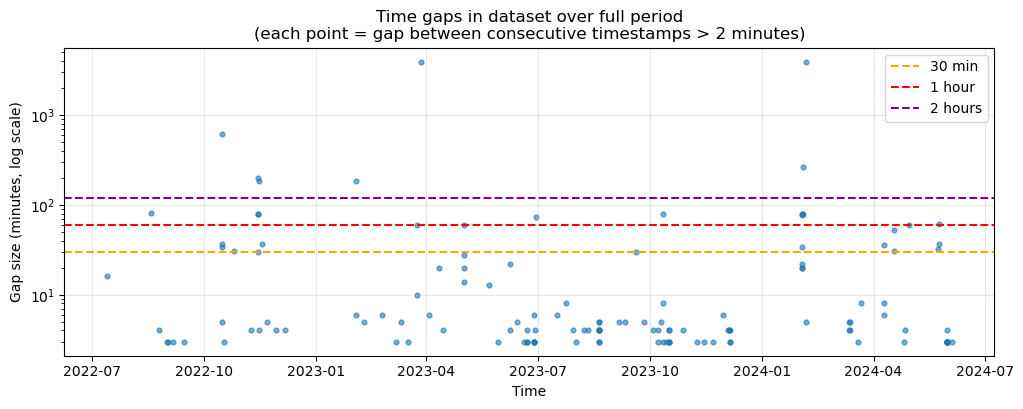

In [17]:
# Convert gap sizes to minutes
gap_minutes = gaps.dt.total_seconds() / 60

plt.figure(figsize=(12, 4))
plt.scatter(
    gaps.index,          # time where gap ends
    gap_minutes,         # gap size
    s=12,
    alpha=0.6
)

plt.yscale("log")
plt.ylabel("Gap size (minutes, log scale)")
plt.xlabel("Time")
plt.title(
    "Time gaps in dataset over full period\n"
    "(each point = gap between consecutive timestamps > 2 minutes)"
)

# Optional reference lines (useful for decision-making)
plt.axhline(30, color="orange", linestyle="--", label="30 min")
plt.axhline(60, color="red", linestyle="--", label="1 hour")
plt.axhline(120, color="purple", linestyle="--", label="2 hours")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



In [21]:
compound_vars = [
    "t1_n2o",
    "t1_nh4",
    "t1_no3",
    "t1_po4",
]

compound_gap_blocks = {}

for var in compound_vars:
    is_missing = df_values[var].isna()

    block_id = is_missing.ne(is_missing.shift()).cumsum()

    blocks = (
        df_values[is_missing]
        .groupby(block_id)
        .apply(
            lambda x: pd.Series({
                "start": x.index[0],
                "end": x.index[-1],
                "duration": x.index[-1] - x.index[0],
                "n_rows": len(x),
            })
        )
        .sort_values("duration", ascending=False)
    )

    compound_gap_blocks[var] = blocks

compound_gap_blocks["t1_n2o"].head(10)
compound_gap_blocks["t1_nh4"].head(10)



,start,end,duration,n_rows
t1_nh4,,,,
238586,2023-03-24 13:26:00+00:00,2023-03-27 07:51:00+00:00,2 days 18:25:00,8
117148,2022-10-15 08:40:00+00:00,2022-10-15 19:11:00+00:00,0 days 10:31:00,6
432354,2024-02-02 15:15:00+00:00,2024-02-03 01:24:00+00:00,0 days 10:09:00,15
138678,2022-11-14 07:11:00+00:00,2022-11-14 13:42:00+00:00,0 days 06:31:00,5
192736,2023-02-02 08:26:00+00:00,2023-02-02 11:37:00+00:00,0 days 03:11:00,4
246996,2023-05-01 09:18:00+00:00,2023-05-01 11:02:00+00:00,0 days 01:44:00,5
522384,2024-05-24 02:42:00+00:00,2024-05-24 04:16:00+00:00,0 days 01:34:00,3
501838,2024-04-17 09:28:00+00:00,2024-04-17 10:51:00+00:00,0 days 01:23:00,3
117190,2022-10-15 19:59:00+00:00,2022-10-15 20:42:00+00:00,0 days 00:43:00,5


In [26]:
df_values["any_compound_missing"] = (
    df_values[compound_vars].isna().any(axis=1)
)

df_values["compound_missing_block"] = (
    df_values["any_compound_missing"]
    .ne(df_values["any_compound_missing"].shift())
    .cumsum()
)

compound_missing_blocks = (
    df_values[df_values["any_compound_missing"]]
    .groupby("compound_missing_block")
    .apply(
        lambda x: pd.Series({
            "start": x.index[0],
            "end": x.index[-1],
            "duration": x.index[-1] - x.index[0],
            "n_rows": len(x),
        })
    )
    .sort_values("duration", ascending=False)
)

compound_missing_blocks.head(10)




,start,end,duration,n_rows
compound_missing_block,,,,
216972,2024-02-05 19:36:00+00:00,2024-03-18 10:43:00+00:00,41 days 15:07:00,59911
184684,2023-09-01 14:50:00+00:00,2023-10-11 08:38:00+00:00,39 days 17:48:00,43464
216970,2024-01-15 19:22:00+00:00,2024-02-05 19:34:00+00:00,21 days 00:12:00,25724
219730,2024-04-12 22:05:00+00:00,2024-04-25 12:59:00+00:00,12 days 14:54:00,18020
184368,2023-08-22 00:54:00+00:00,2023-09-01 08:40:00+00:00,10 days 07:46:00,12989
158218,2023-06-20 12:07:00+00:00,2023-06-28 08:34:00+00:00,7 days 20:27:00,11272
225112,2024-05-24 05:01:00+00:00,2024-05-30 17:15:00+00:00,6 days 12:14:00,9374
225582,2024-06-05 16:31:00+00:00,2024-06-11 21:59:00+00:00,6 days 05:28:00,8969
158216,2023-06-14 10:21:00+00:00,2023-06-20 12:05:00+00:00,6 days 01:44:00,8741


In [27]:
df_values["n2o_missing"] = df_values["t1_n2o"].isna()

df_values["n2o_missing_block"] = (
    df_values["n2o_missing"]
    .ne(df_values["n2o_missing"].shift())
    .cumsum()
)

n2o_missing_blocks = (
    df_values[df_values["n2o_missing"]]
    .groupby("n2o_missing_block")
    .apply(
        lambda x: pd.Series({
            "start": x.index[0],
            "end": x.index[-1],
            "duration": x.index[-1] - x.index[0],
            "n_rows": len(x),
        })
    )
    .sort_values("duration", ascending=False)
)

n2o_missing_blocks.head(10)


,start,end,duration,n_rows
n2o_missing_block,,,,
237662,2023-03-24 13:26:00+00:00,2023-03-27 07:51:00+00:00,2 days 18:25:00,8
117232,2022-10-15 08:40:00+00:00,2022-10-15 19:11:00+00:00,0 days 10:31:00,6
432372,2024-02-02 15:15:00+00:00,2024-02-03 01:24:00+00:00,0 days 10:09:00,15
139056,2022-11-14 07:11:00+00:00,2022-11-14 13:42:00+00:00,0 days 06:31:00,5
359480,2023-09-23 05:29:00+00:00,2023-09-23 10:49:00+00:00,0 days 05:20:00,161
342562,2023-09-03 08:35:00+00:00,2023-09-03 12:55:00+00:00,0 days 04:20:00,131
368908,2023-10-08 09:01:00+00:00,2023-10-08 12:21:00+00:00,0 days 03:20:00,101
365612,2023-10-03 07:41:00+00:00,2023-10-03 10:59:00+00:00,0 days 03:18:00,99
344132,2023-09-05 04:11:00+00:00,2023-09-05 07:23:00+00:00,0 days 03:12:00,97


In [28]:
# Helper function for gap analysis 
def gap_duration_summary(blocks, thresholds_hours=[2, 6, 12, 24]):
    """
    blocks: DataFrame with a 'duration' column (Timedelta)
    """
    durations_h = blocks["duration"].dt.total_seconds() / 3600

    summary = {}

    for h in thresholds_hours:
        summary[f">= {h}h"] = (durations_h >= h).sum()

    summary["total_blocks"] = len(blocks)

    return pd.Series(summary)


In [29]:
n2o_gap_stats = gap_duration_summary(n2o_missing_blocks)
n2o_gap_stats

>= 2h               14
>= 6h                4
>= 12h               1
>= 24h               1
total_blocks    274621
dtype: int64

In [30]:
compound_gap_stats = pd.DataFrame({
    var: gap_duration_summary(blocks)
    for var, blocks in compound_gap_blocks.items()
}).T

compound_gap_stats

,>= 2h,>= 6h,>= 12h,>= 24h,total_blocks
t1_n2o,14,4,1,1,274621
t1_nh4,5,4,1,1,274633
t1_no3,5,3,2,2,274529
t1_po4,3,3,0,0,272451


In [31]:
compound_any_gap_stats = gap_duration_summary(compound_missing_blocks)
compound_any_gap_stats


>= 2h               96
>= 6h               61
>= 12h              46
>= 24h              40
total_blocks    112791
dtype: int64

In [32]:
def fraction_time_lost(blocks, total_duration):
    return blocks["duration"].sum() / total_duration

total_duration = df_values.index.max() - df_values.index.min()

pd.Series({
    "n2o_missing_fraction": fraction_time_lost(n2o_missing_blocks, total_duration),
    "compound_any_missing_fraction": fraction_time_lost(compound_missing_blocks, total_duration),
})


n2o_missing_fraction             0.037108
compound_any_missing_fraction    0.358154
dtype: float64

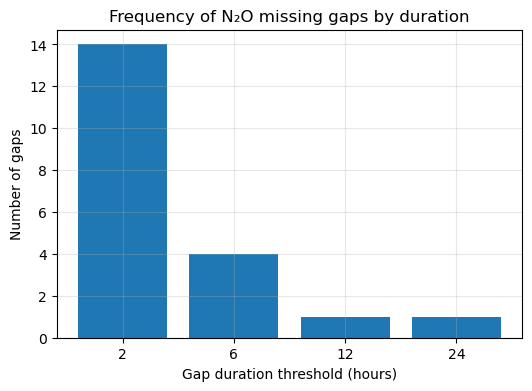

In [34]:

thresholds = [2, 6, 12, 24]
counts = [n2o_gap_stats[f">= {h}h"] for h in thresholds]

plt.figure(figsize=(6, 4))
plt.bar([str(h) for h in thresholds], counts)
plt.xlabel("Gap duration threshold (hours)")
plt.ylabel("Number of gaps")
plt.title("Frequency of N₂O missing gaps by duration")
plt.grid(True, alpha=0.3)
plt.show()


In [35]:
BREAK_THRESHOLD = pd.Timedelta("2D")

large_n2o_gaps = n2o_missing_blocks[
    n2o_missing_blocks["duration"] >= BREAK_THRESHOLD
]


In [36]:
large_n2o_gaps[["start", "end", "duration"]]


,start,end,duration
n2o_missing_block,,,
237662,2023-03-24 13:26:00+00:00,2023-03-27 07:51:00+00:00,2 days 18:25:00


In [41]:
df_t1 = df_t1.sort_index()

compound_vars = ["t1_n2o", "t1_nh4", "t1_no3", "t1_po4"]

# Flag rows where ANY compound is missing
df_t1["any_compound_missing"] = df_t1[compound_vars].isna().any(axis=1)

# Identify contiguous missing/non-missing blocks
df_t1["compound_missing_block"] = (
    df_t1["any_compound_missing"]
    .ne(df_t1["any_compound_missing"].shift())
    .cumsum()
)

# Summarize only the missing blocks
compound_missing_blocks_t1 = (
    df_t1[df_t1["any_compound_missing"]]
    .groupby("compound_missing_block")
    .apply(lambda x: pd.Series({
        "start": x.index[0],
        "end": x.index[-1],
        "duration": x.index[-1] - x.index[0],
        "n_rows": len(x),
    }))
    .sort_values("duration", ascending=False)
)

compound_missing_blocks_t1.head(10)


,start,end,duration,n_rows
compound_missing_block,,,,
216972,2024-02-05 19:36:00+00:00,2024-03-18 10:43:00+00:00,41 days 15:07:00,59911
184684,2023-09-01 14:50:00+00:00,2023-10-11 08:38:00+00:00,39 days 17:48:00,43464
216970,2024-01-15 19:22:00+00:00,2024-02-05 19:34:00+00:00,21 days 00:12:00,25724
219730,2024-04-12 22:05:00+00:00,2024-04-25 12:59:00+00:00,12 days 14:54:00,18020
184368,2023-08-22 00:54:00+00:00,2023-09-01 08:40:00+00:00,10 days 07:46:00,12989
158218,2023-06-20 12:07:00+00:00,2023-06-28 08:34:00+00:00,7 days 20:27:00,11272
225112,2024-05-24 05:01:00+00:00,2024-05-30 17:15:00+00:00,6 days 12:14:00,9374
225582,2024-06-05 16:31:00+00:00,2024-06-11 21:59:00+00:00,6 days 05:28:00,8969
158216,2023-06-14 10:21:00+00:00,2023-06-20 12:05:00+00:00,6 days 01:44:00,8741


In [42]:
BREAK_THRESHOLD = pd.Timedelta("2D")

large_compound_gaps_t1 = compound_missing_blocks_t1[
    compound_missing_blocks_t1["duration"] >= BREAK_THRESHOLD
].copy()

print("Large ANY-compound missing gaps (>= 2 days):")
print(large_compound_gaps_t1[["start", "end", "duration", "n_rows"]].head(20))

# Assign segment_id (break at start of each large missing gap)
df_t1["segment_id_anycompound"] = 0
break_times = large_compound_gaps_t1["start"].sort_values()

current_segment = 0
for t in break_times:
    current_segment += 1
    df_t1.loc[df_t1.index >= t, "segment_id_anycompound"] = current_segment


Large ANY-compound missing gaps (>= 2 days):
                                           start                       end  \
compound_missing_block                                                       
216972                 2024-02-05 19:36:00+00:00 2024-03-18 10:43:00+00:00   
184684                 2023-09-01 14:50:00+00:00 2023-10-11 08:38:00+00:00   
216970                 2024-01-15 19:22:00+00:00 2024-02-05 19:34:00+00:00   
219730                 2024-04-12 22:05:00+00:00 2024-04-25 12:59:00+00:00   
184368                 2023-08-22 00:54:00+00:00 2023-09-01 08:40:00+00:00   
158218                 2023-06-20 12:07:00+00:00 2023-06-28 08:34:00+00:00   
225112                 2024-05-24 05:01:00+00:00 2024-05-30 17:15:00+00:00   
225582                 2024-06-05 16:31:00+00:00 2024-06-11 21:59:00+00:00   
158216                 2023-06-14 10:21:00+00:00 2023-06-20 12:05:00+00:00   
81994                  2022-10-25 13:28:00+00:00 2022-10-31 06:34:00+00:00   
225580             

In [43]:
segment_summary_anycompound_t1 = (
    df_t1.groupby("segment_id_anycompound")
    .apply(lambda x: pd.Series({
        "start": x.index.min(),
        "end": x.index.max(),
        "duration": x.index.max() - x.index.min(),
        "n_rows": len(x),
        "any_compound_missing_fraction": x["any_compound_missing"].mean(),
        "n2o_missing_fraction": x["t1_n2o"].isna().mean(),
    }))
    .sort_values("start")
)

segment_summary_anycompound_t1


,start,end,duration,n_rows,any_compound_missing_fraction,n2o_missing_fraction
segment_id_anycompound,,,,,,
0,2022-06-11 22:01:00+00:00,2022-06-21 05:35:00+00:00,9 days 07:34:00,12589,0.635237,0.468266
1,2022-06-21 05:36:00+00:00,2022-07-15 16:37:00+00:00,24 days 11:01:00,27098,0.491808,0.350616
2,2022-07-15 16:38:00+00:00,2022-07-31 11:42:00+00:00,15 days 19:04:00,19773,0.514388,0.429475
3,2022-07-31 11:43:00+00:00,2022-09-01 03:35:00+00:00,31 days 15:52:00,38508,0.519944,0.409941
4,2022-09-01 03:37:00+00:00,2022-10-21 10:43:00+00:00,50 days 07:06:00,57952,0.542501,0.385077
5,2022-10-21 10:44:00+00:00,2022-10-25 13:27:00+00:00,4 days 02:43:00,5889,0.994227,0.497877
6,2022-10-25 13:28:00+00:00,2022-11-01 15:30:00+00:00,7 days 02:02:00,8867,0.925228,0.490358
7,2022-11-01 15:31:00+00:00,2022-11-18 23:15:00+00:00,17 days 07:44:00,16148,0.371439,0.249009
8,2022-11-18 23:16:00+00:00,2023-03-11 05:14:00+00:00,112 days 05:58:00,121929,0.476433,0.338098


In [44]:
df_t1_model_anycompound = df_t1[~df_t1["any_compound_missing"]].copy()


In [45]:
min_duration = pd.Timedelta("14D")
max_missing_frac = 0.20

usable_segments = segment_summary_anycompound_t1[
    (segment_summary_anycompound_t1["duration"] >= min_duration) &
    (segment_summary_anycompound_t1["any_compound_missing_fraction"] <= max_missing_frac)
].index

df_t1_model_anycompound = df_t1[
    (df_t1["segment_id_anycompound"].isin(usable_segments)) &
    (~df_t1["any_compound_missing"])
].copy()


In [46]:
compound_missing_blocks_t1[["start", "end", "duration"]].head(5)


,start,end,duration
compound_missing_block,,,
216972,2024-02-05 19:36:00+00:00,2024-03-18 10:43:00+00:00,41 days 15:07:00
184684,2023-09-01 14:50:00+00:00,2023-10-11 08:38:00+00:00,39 days 17:48:00
216970,2024-01-15 19:22:00+00:00,2024-02-05 19:34:00+00:00,21 days 00:12:00
219730,2024-04-12 22:05:00+00:00,2024-04-25 12:59:00+00:00,12 days 14:54:00
184368,2023-08-22 00:54:00+00:00,2023-09-01 08:40:00+00:00,10 days 07:46:00


In [47]:
# Make sure segment_id_anycompound exists
if "segment_id_anycompound" not in df_t1.columns:
    raise ValueError("segment_id_anycompound not found in df_t1")

# Create indicator columns
segment_dummies = pd.get_dummies(
    df_t1["segment_id_anycompound"],
    prefix="seg",
    dtype=int
)

# Join back to df_t1
df_t1 = df_t1.join(segment_dummies)


In [48]:
segment_counts = df_t1["segment_id_anycompound"].value_counts().sort_index()
segment_counts


segment_id_anycompound
0      12589
1      27098
2      19773
3      38508
4      57952
5       5889
6       8867
7      16148
8     121929
9      12008
10      4783
11      6234
12     54949
13     18853
14      8742
15     64428
16     13338
17    130791
18     25725
19     79877
20     43071
21     10135
22      7810
23      8969
Name: count, dtype: int64

In [50]:
df_t1.groupby("segment_id_anycompound")[
    ["t1_n2o", "t1_nh4", "t1_no3", "t1_po4"]
].apply(lambda x: x.isna().mean().round(2))


,t1_n2o,t1_nh4,t1_no3,t1_po4
segment_id_anycompound,,,,
0,0.47,0.47,0.47,0.47
1,0.35,0.35,0.35,0.35
2,0.43,0.42,0.43,0.43
3,0.41,0.41,0.41,0.41
4,0.39,0.38,0.38,0.38
5,0.50,0.50,0.50,0.50
6,0.49,0.42,0.50,0.42
7,0.25,0.25,0.25,0.25
8,0.34,0.34,0.34,0.34
